In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('C:/Users/lenovo/Desktop/Git project/hotel_booking_cleaned_data.csv')
df.head()

,Customer ID,Customer Country,Booking_ID,Hotel,City,Booking Date,Lead Time,Arrival Date,Adults,Childrens,...,No. of Week Nights,Total Nights Stay,Meal Type,Booking Status,Customer Cancel Count,Average Daily Rate,Market Segment,Reserved Room Type,Assigned Room Type,Special Request
0,CUST_570,India,INN00001,Resort Hotel,Hyderabad,20-Aug-23,342,27-Jul-24,2,0,...,5,7,Breakfast,0,1,135,Online Self / TA,Deluxe,Premium,0
1,CUST_164,UK,INN00002,Resort Hotel,Goa,20-Mar-23,405,28-Apr-24,2,0,...,3,4,Not Selected,1,1,0,Online Self / TA,Deluxe,Deluxe,0
2,CUST_420,India,INN00003,Resort Hotel,Mumbai,3-Sep-24,7,10-Sep-24,2,0,...,3,4,Breakfast,0,0,75,Direct,Standard,Standard,0
3,CUST_278,Australia,INN00004,City Hotel,Kochi,1-Aug-24,13,14-Aug-24,2,0,...,2,2,Breakfast,1,1,75,Online Self / TA,Standard,Standard,0
4,CUST_572,India,INN00005,City Hotel,Jaipur,31-Aug-24,14,14-Sep-24,2,0,...,2,3,Not Selected,1,2,98,Online Self / TA,Standard,Deluxe,1


In [4]:
# check info
df.info()
# check missing values
df.isnull().sum()
# remove missing values
df = df.dropna()
# remove duplicates
df.drop_duplicates(inplace=True)
# Convert string dates to datetime using correct format
df['Arrival Date'] = pd.to_datetime(df['Arrival Date'], format='%d-%b-%y')
df['Booking Date'] = pd.to_datetime(df['Booking Date'], format='%d-%b-%y')
#create new column for month
df['Month'] = df['Arrival Date'].dt.month


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Customer ID            1000 non-null   str  
 1   Customer Country       1000 non-null   str  
 2   Booking_ID             1000 non-null   str  
 3   Hotel                  1000 non-null   str  
 4   City                   1000 non-null   str  
 5   Booking Date           1000 non-null   str  
 6   Lead Time              1000 non-null   int64
 7   Arrival Date           1000 non-null   str  
 8   Adults                 1000 non-null   int64
 9   Childrens              1000 non-null   int64
 10  Total Guests           1000 non-null   int64
 11  No. of Weekend Nights  1000 non-null   int64
 12  No. of Week Nights     1000 non-null   int64
 13  Total Nights Stay      1000 non-null   int64
 14  Meal Type              1000 non-null   str  
 15  Booking Status         1000 non-null   int64
 16  

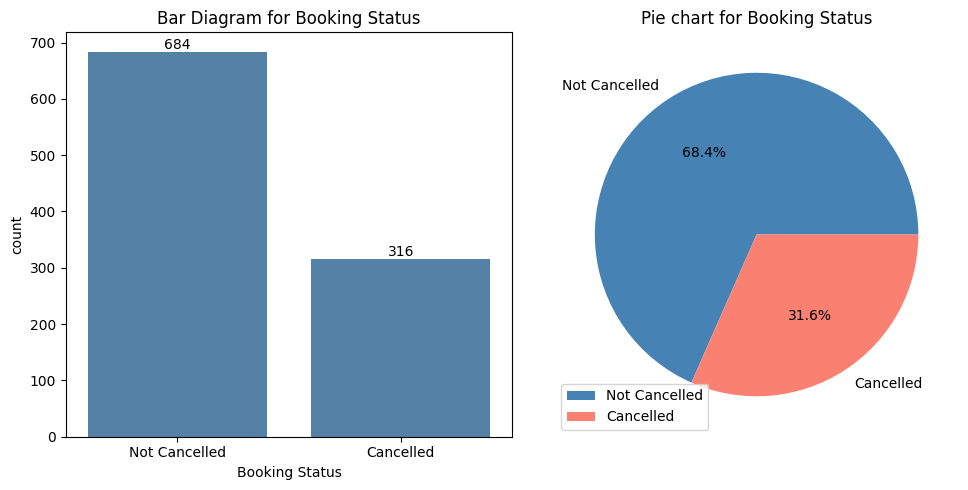

In [5]:
#Univariate Analysis of Booking Status Distribution
# Show both cleanly
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Countplot
ax = sns.countplot(x='Booking Status', data=df, ax=axes[0], color='steelblue')
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Not Cancelled','Cancelled'])
for p in ax.patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')
axes[0].set_title("Bar Diagram for Booking Status")
# Pie chart
counts = df['Booking Status'].value_counts()
axes[1].pie(counts,
            labels=['Not Cancelled','Cancelled'],
            autopct='%1.1f%%',
            colors=['steelblue','salmon'])
axes[1].set_title("Pie chart for Booking Status")
plt.legend()
plt.tight_layout()
plt.show()


### Booking Status Insight
Out of total bookings, 684(i.e 68.4%) bookings were not cancelled while 316 (i.e 31.6%)bookings were cancelled.

This indicates that the majority of customers complete their bookings successfully. 
However, a significant portion (around 31.6%) of bookings are cancelled, which suggests 
that cancellation is an important factor to consider in hotel booking analysis.

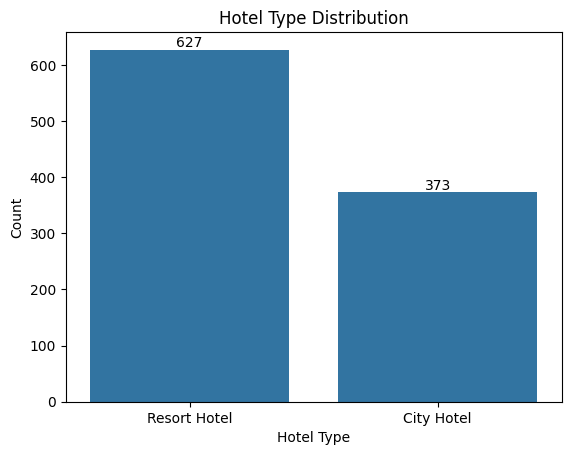

In [7]:
#Univariate Analysis of Hotel Type Distribution
# Countplot to show number of bookings for each hotel type
ax = sns.countplot(x='Hotel', data=df)
# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.show()

### Hotel Type Insight
Out of total bookings, 627 bookings are for Resort Hotels while 373 bookings are for City Hotels.

This indicates that Resort Hotels are more preferred by customers compared to City Hotels. 
The higher number of bookings for Resort Hotels suggests that customers are more interested 
in leisure travel and vacation stays rather than city-based or business-related stays.

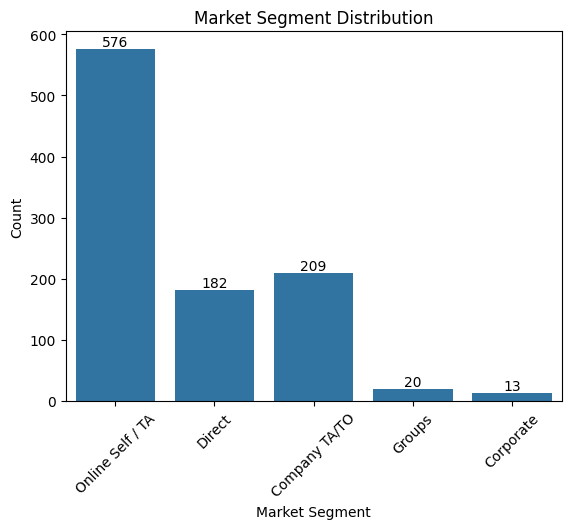

In [6]:

#Univariate Analysis of Market Segment Distribution
# Countplot to show number of bookings for each market segment
ax = sns.countplot(x='Market Segment', data=df)
# Add count labels on bars
ax.bar_label(ax.containers[0])

plt.xticks(rotation=45)
plt.title("Market Segment Distribution")
plt.xlabel("Market Segment")
plt.ylabel("Count")
plt.show()

### Market Segment Insight
Out of total bookings, Online TA has the highest bookings (576), followed by Company TA/TO (209) and Direct bookings (182). 
Other segments such as Groups (20) and Corporate (13) contribute very less to total bookings.

This indicates that most customers prefer booking through online travel agents, showing the importance of online platforms in hotel bookings, while corporate and group bookings are comparatively lower.

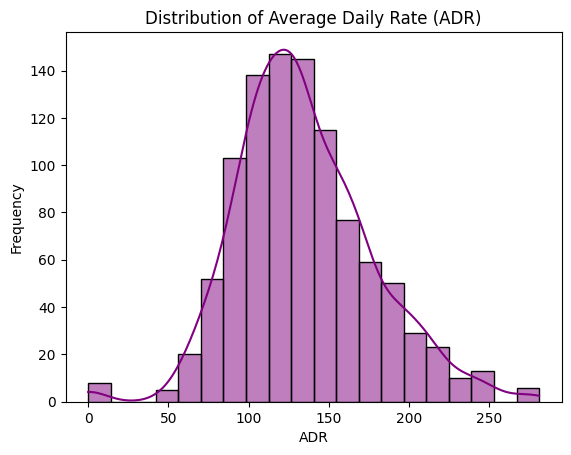

In [7]:
#Distribution of Average Daily Rate (ADR)
# Histogram shows how ADR values are distributed across bookings
sns.histplot(df['Average Daily Rate'], bins=20, kde=True, color='purple')
plt.title("Distribution of Average Daily Rate (ADR)")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.show()

### Average Daily Rate Insights
The ADR (Average Daily Rate) distribution is right-skewed, indicating that most bookings are concentrated in the mid-price range, mainly between ₹110 and ₹140. This represents the core pricing segment of the hotel business and shows that most customers prefer moderately priced stays.

A small number of bookings have very low or zero ADR, which may indicate complimentary stays or data anomalies, while a few high-value bookings above ₹180 represent premium segments. Overall, the pricing structure is stable, with most revenue generated from mid-range bookings and limited influence from extreme values.

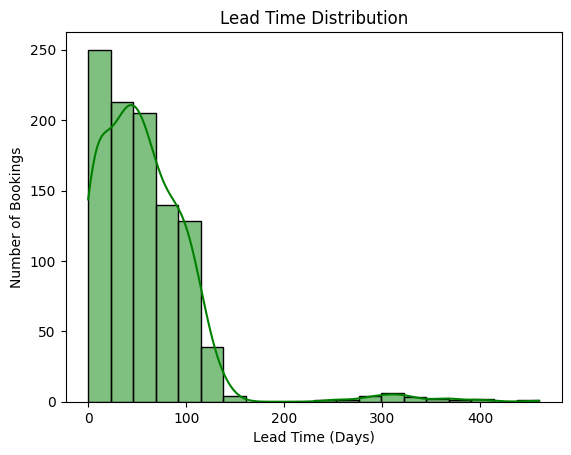

In [8]:
#Lead Time Distribution
# Histogram shows how far in advance customers book their rooms
df.columns = df.columns.str.strip()   #remove extra spaces
sns.histplot(df['Lead Time'], bins=20, kde=True, color='green')
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")
plt.show()

### Lead Time Insights
The Lead Time distribution is strongly right-skewed, showing that most customers book their stays within a short period before arrival (0–50 days). This indicates a preference for last-minute or short-term booking behavior.

As lead time increases, the number of bookings decreases significantly, with very few long-advance bookings beyond 100 days and a few rare outliers above 300 days. Overall, the hotel mainly receives short-to-medium term bookings with limited long-term reservations.

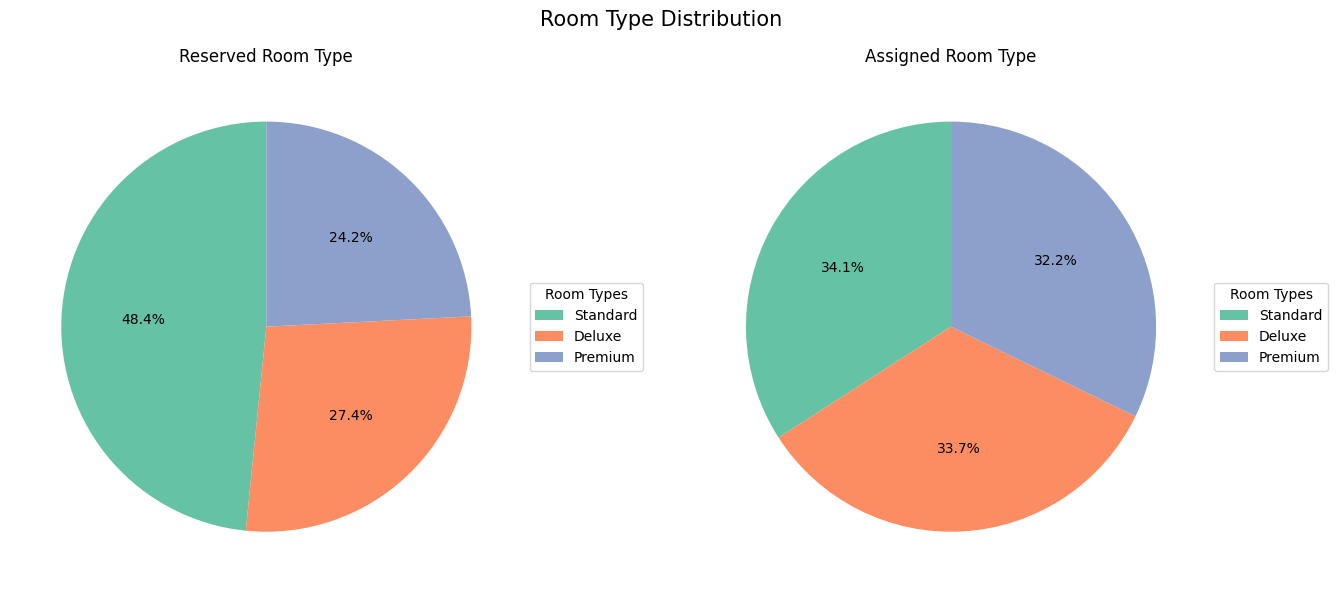

In [9]:
#Univariate analysis of Room type

fig, axes = plt.subplots(1, 2, figsize=(14,6))
# Reserved Room Type
res_counts = df['Reserved Room Type'].value_counts()
wedges1, texts1, autotexts1 = axes[0].pie(
    res_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors = ['#66c2a5', '#fc8d62', '#8da0cb'] 
)
axes[0].set_title("Reserved Room Type")
# Add legend
axes[0].legend(wedges1, res_counts.index,
               title="Room Types",
               loc="center left",
               bbox_to_anchor=(1, 0.5))

# Assigned Room Type
ass_counts = df['Assigned Room Type'].value_counts()
wedges2, texts2, autotexts2 = axes[1].pie(
    ass_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors = ['#66c2a5', '#fc8d62','#8da0cb']  
)
axes[1].set_title("Assigned Room Type")
# Add legend
axes[1].legend(wedges2, ass_counts.index,
               title="Room Types",
               loc="center left",
               bbox_to_anchor=(1, 0.5))

fig.suptitle("Room Type Distribution", fontsize=15)
plt.tight_layout()
plt.show()

### Room Type Insights
The Reserved Room Type chart shows that most customers prefer Standard rooms (48.4%), followed by Deluxe and Premium. This indicates that demand is highly concentrated in lower-priced room categories, reflecting price-sensitive customer behavior.
However, the Assigned Room Type is almost evenly distributed across all room types. This suggests that many customers are being upgraded from Standard to higher categories due to limited availability. While this can improve customer satisfaction, it may lead to revenue loss and highlights inefficiencies in room allocation and inventory management.

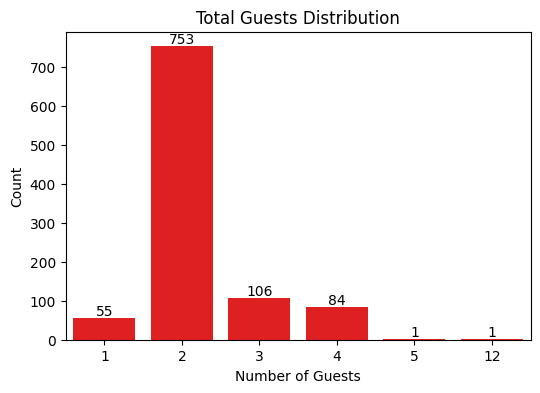

In [10]:
#Univariate analysis of total guests 
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Total Guests', data=df, color='red')
# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )
plt.title("Total Guests Distribution")
plt.xlabel("Number of Guests")
plt.ylabel("Count")
plt.grid(False)
plt.show()

### Total Guest Insights
The hotel is primarily used for two-guest bookings (~75%), indicating that most stays involve paired travelers rather than single or large groups. A smaller portion of bookings comes from 3–4 guests (~19%), showing some demand from small families or groups, while solo stays are minimal. 
Overall,the property serves a mixed customer base, with a strong preference toward double-occupancy stays.

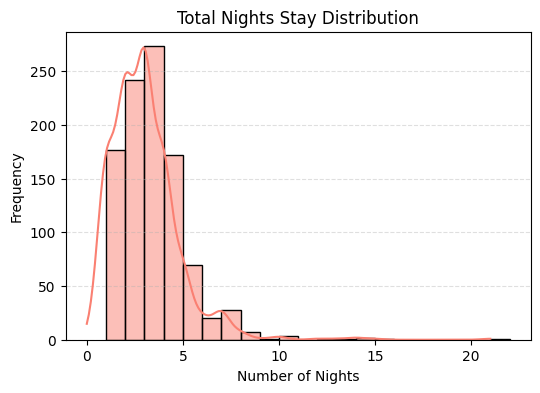

In [11]:
#Univariate analysis of total nights stays
plt.figure(figsize=(6,4))
sns.histplot(df['Total Nights Stay'],
             bins=range(1, df['Total Nights Stay'].max() + 2),
             kde=True,
             color='salmon')
plt.title("Total Nights Stay Distribution")
plt.xlabel("Number of Nights")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

The hotel is mainly used for short stays of 2–4 nights, which forms the peak booking duration. Very few guests stay beyond 5 nights, and long stays are rare outliers. The distribution is right-skewed, showing a strong preference for short-duration visits, making short stays the core usage pattern of the hotel.

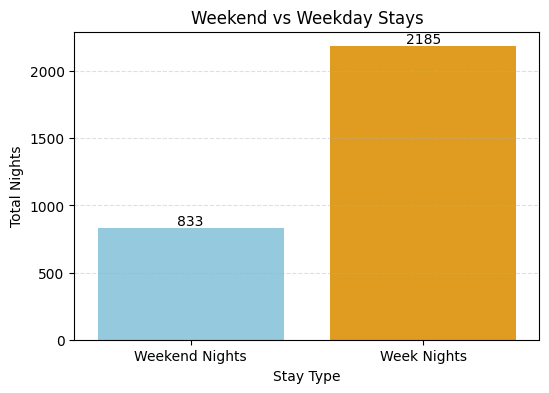

In [12]:
#Univariate analysis of stay type
weekend = df['No. of Weekend Nights'].sum()
weekday = df['No. of Week Nights'].sum()
data = {
    "Stay Type": ["Weekend Nights", "Week Nights"],
    "Total Nights": [weekend, weekday]
}
plt.figure(figsize=(6,4))
ax = sns.barplot(
    x="Stay Type",
    y="Total Nights",
    data=data,
    hue="Stay Type",      # fix for warning
    palette=['skyblue', 'orange'],
    legend=False
)
for i, v in enumerate([weekend, weekday]):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.title("Weekend vs Weekday Stays")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

The hotel is mostly used for short stays of 2–4 nights, meaning guests usually come for quick trips. It also gets more bookings on weekdays than weekends, so it is busy throughout the week, not just on weekends.
Overall, most guests stay for a short time and the hotel has steady demand during weekdays.

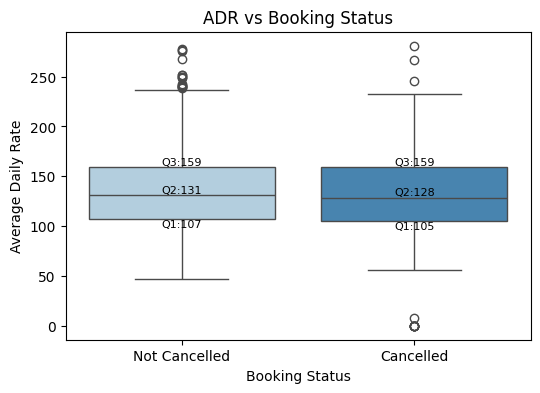

In [13]:
# Box Plot of ADR vs Booking Status
df['Booking Status Label'] = df['Booking Status'].map({
    0: 'Not Cancelled',
    1: 'Cancelled'
})
plt.figure(figsize=(6,4))
order = ['Not Cancelled', 'Cancelled']
ax = sns.boxplot(
    x='Booking Status Label',
    y='Average Daily Rate',
    data=df,
    order=order,
    hue='Booking Status Label',   # fix for warning
    palette='Blues',
    legend=False
)
#for finding Q1,Q2,Q3
for i, label in enumerate(order):
    subset = df[df['Booking Status Label'] == label]['Average Daily Rate']
    q1 = subset.quantile(0.25)
    q2 = subset.quantile(0.50)
    q3 = subset.quantile(0.75)
    plt.text(i, q1, f'Q1:{q1:.0f}', ha='center', va='top', fontsize=8)
    plt.text(i, q2, f'Q2:{q2:.0f}', ha='center', va='bottom', fontsize=8)
    plt.text(i, q3, f'Q3:{q3:.0f}', ha='center', va='bottom', fontsize=8)
plt.title("ADR vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Daily Rate")
plt.show()

The boxplot shows that the Average Daily Rate (ADR) is almost similar for both cancelled and not cancelled bookings. The median value and the overall price range are nearly the same in both groups, which indicates that pricing does not have a strong impact on whether a booking is cancelled or not.

There are a few outliers in both groups, including very low ADR values (around 0) and some very high-priced bookings. These represent unusual or special cases, but they do not significantly affect the overall pattern. Overall, cancellations are not mainly driven by differences in price.

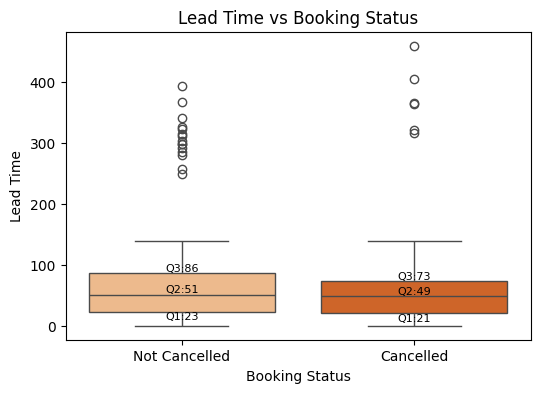

In [14]:
# Boxplot of lead time vs booking status

df['Booking Status Label'] = df['Booking Status'].map({
    0: 'Not Cancelled',
    1: 'Cancelled'
})
plt.figure(figsize=(6,4))
order = ['Not Cancelled', 'Cancelled']
sns.boxplot(
    x='Booking Status Label',
    y='Lead Time',
    data=df,
    order=order,
    hue='Booking Status Label',   # fix
    palette='Oranges',
    legend=False
)
#for finding Q1,Q2,Q3
for i, label in enumerate(order):
    subset = df[df['Booking Status Label'] == label]['Lead Time']
    
    q1 = subset.quantile(0.25)
    q2 = subset.quantile(0.50)
    q3 = subset.quantile(0.75)

    plt.text(i, q1, f'Q1:{q1:.0f}', ha='center', va='top', fontsize=8)
    plt.text(i, q2, f'Q2:{q2:.0f}', ha='center', va='bottom', fontsize=8)
    plt.text(i, q3, f'Q3:{q3:.0f}', ha='center', va='bottom', fontsize=8)
plt.title("Lead Time vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Lead Time")
plt.show()

The boxplot shows that lead time is almost the same for both cancelled and not cancelled bookings, so booking early or late does not strongly affect cancellations. Both groups have similar median and spread, with only a few extreme outliers where very early bookings sometimes get cancelled. 
Overall,lead time is not a strong factor in cancellations in this dataset.

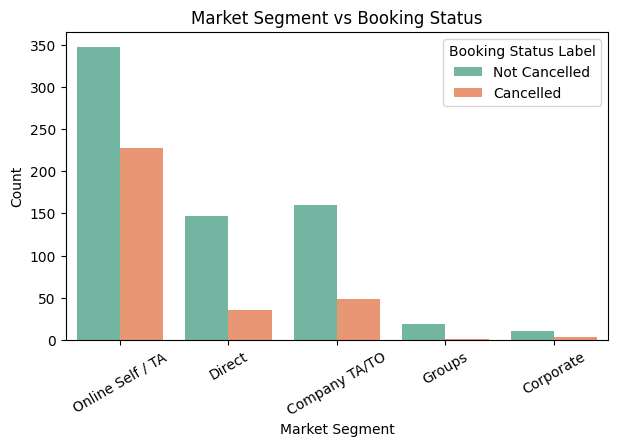

In [15]:
#Market segment vs booking status analysis
df['Booking Status Label'] = df['Booking Status'].map({
    0: 'Not Cancelled',
    1: 'Cancelled'
})
plt.figure(figsize=(7,4))
sns.countplot(x='Market Segment',
              hue='Booking Status Label',
              data=df,
              palette='Set2')
plt.title("Market Segment vs Booking Status")
plt.xlabel("Market Segment")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()


The chart shows that booking source has a strong impact on cancellations. Online bookings have the highest number of cancellations compared to other segments, while direct bookings are much more stable with fewer cancellations. Corporate and travel agent bookings also show lower cancellation levels and are more reliable.

Overall, cancellations depend more on the booking channel than on price or lead time, with online platforms being the most risky segment.





## -Customer Segmentation

In this section, we group customers based on booking behavior such as lead time and stay duration.

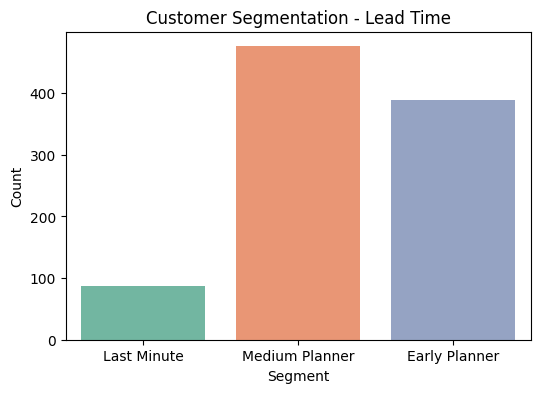

In [34]:
#Customer Segmentation – Lead Time Distribution
# Create Lead Time Segments (3 groups)
df['Lead Time Segment'] = pd.cut(
    df['Lead Time'],
    bins=[0, 7, 60, 365],
    labels=['Last Minute', 'Medium Planner', 'Early Planner']
)
# Plot graph
plt.figure(figsize=(6,4))
sns.countplot(
    x='Lead Time Segment',
    data=df,
    hue='Lead Time Segment',
    palette='Set2',
    legend=False,
    dodge=False   # fix bar size
)
plt.title("Customer Segmentation - Lead Time")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

Most customers are medium planners, booking their stays 1–3 months in advance, which forms the main booking base of the hotel. A significant number are last-minute bookers, showing strong short-notice demand, while only a small group are early planners.

Overall, the hotel has a stable and predictable booking pattern, with opportunities to use early-bird pricing for advance bookings and dynamic pricing for last-minute demand.

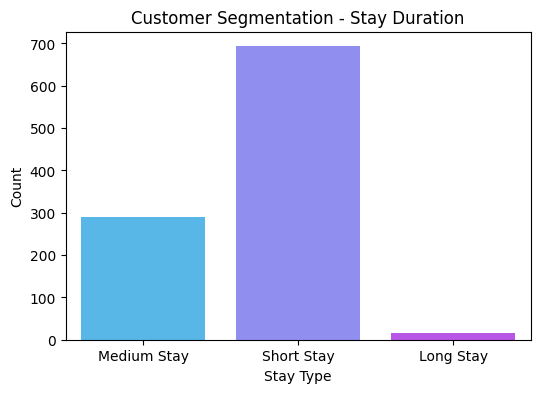

In [17]:
#Customer Segmentation- Stay duration
def stay_segment(x):
    if x <= 3:
        return "Short Stay"
    elif x <= 7:
        return "Medium Stay"
    else:
        return "Long Stay"
df['Stay Segment'] = df['Total Nights Stay'].apply(stay_segment)
plt.figure(figsize=(6,4))
sns.countplot(
    x='Stay Segment',
    data=df,
    hue='Stay Segment',   # fixes warning
    palette='cool',
    legend=False
)
plt.title("Customer Segmentation - Stay Duration")
plt.xlabel("Stay Type")
plt.ylabel("Count")
plt.show()

The chart shows that most customers are short-stay guests, staying only 1–3 nights, making this the main customer group for the hotel. A smaller portion are medium-stay guests, while very few customers stay for long durations.

Overall, the hotel mainly serves quick trips and short visits, with high guest turnover and limited long stays. This suggests focusing on short-stay demand while also encouraging medium-stay packages to increase revenue.

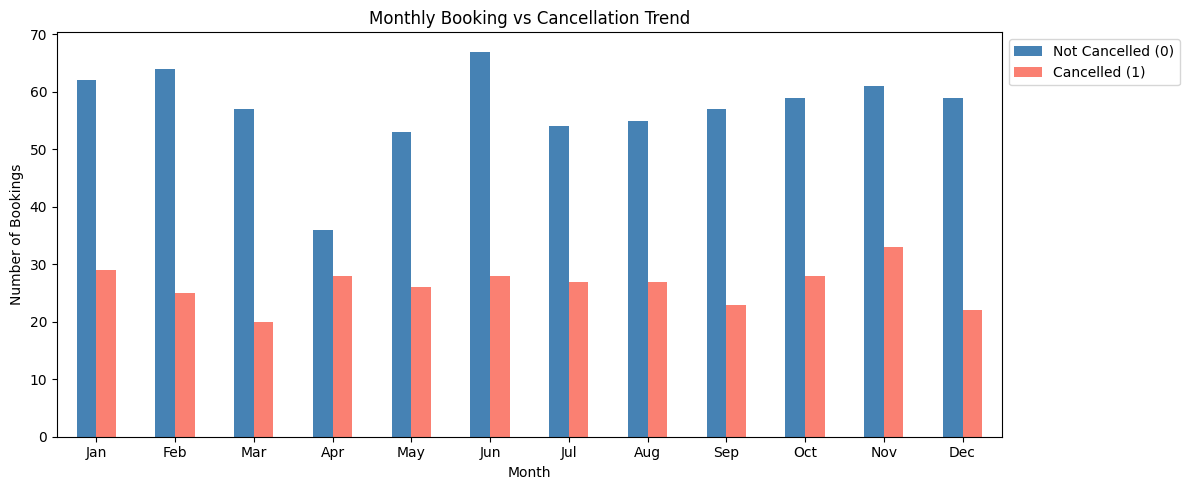

In [39]:
#Monthly booking and Cancellation Analysis
# Clean column names
df.columns = df.columns.str.strip()
# Convert Month if needed (from date column)
# If you have 'Arrival Date'
df['Month'] = pd.to_datetime(df['Arrival Date']).dt.strftime('%b')
# Month order
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
# Grouping
monthly_data = df.groupby('Month')['Booking Status'].value_counts().unstack().fillna(0)
# Reindex
monthly_data = monthly_data.reindex(month_order)
# Plot
ax = monthly_data.plot(kind='bar', figsize=(12,5), color=['steelblue','salmon'])
plt.title("Monthly Booking vs Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.legend(['Not Cancelled (0)', 'Cancelled (1)'],
           loc='upper left',
           bbox_to_anchor=(1,1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Monthly Booking and Cancellation Analysis
June month shows the highest booking volume, indicating peak demand and strong travel activity. November month records the highest cancellations, making it the most risky month for lost revenue. March month shows relatively low cancellations, making it the most stable and reliable month.

Overall, mid-year months (June–August) show steady performance with high bookings and stable cancellations, while November month requires attention due to higher cancellation rates.

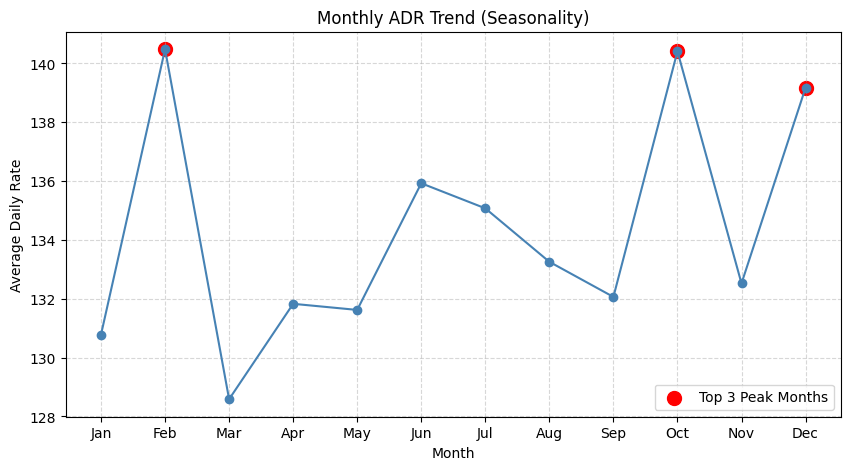

In [40]:
# Monthly ADR Trend 
plt.figure(figsize=(10,5))
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_adr = df.groupby('Month')['Average Daily Rate'].mean().reindex(month_order)
# Line plot
plt.plot(monthly_adr.index, monthly_adr.values, marker='o', color='steelblue')
plt.title("Monthly ADR Trend (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Daily Rate")
plt.grid(True, linestyle='--', alpha=0.5)
# Highlight Top 3 peak months
top3 = monthly_adr.sort_values(ascending=False).head(3)
plt.scatter(top3.index, top3.values, color='red', s=100, label='Top 3 Peak Months')
plt.legend()
plt.show()

### Monthly ADR Trend Insights
The Monthly ADR Trend shows clear seasonality in pricing. February and October record the highest ADR (~140), indicating peak demand and premium pricing periods, while March shows the lowest ADR (~128), reflecting a low-demand season.

Overall, ADR fluctuates significantly across months, with (Oct–Jan) showing stronger revenue performance. This indicates that hotel pricing is highly demand-driven and varies based on seasonal travel patterns.

<Figure size 1600x1000 with 0 Axes>

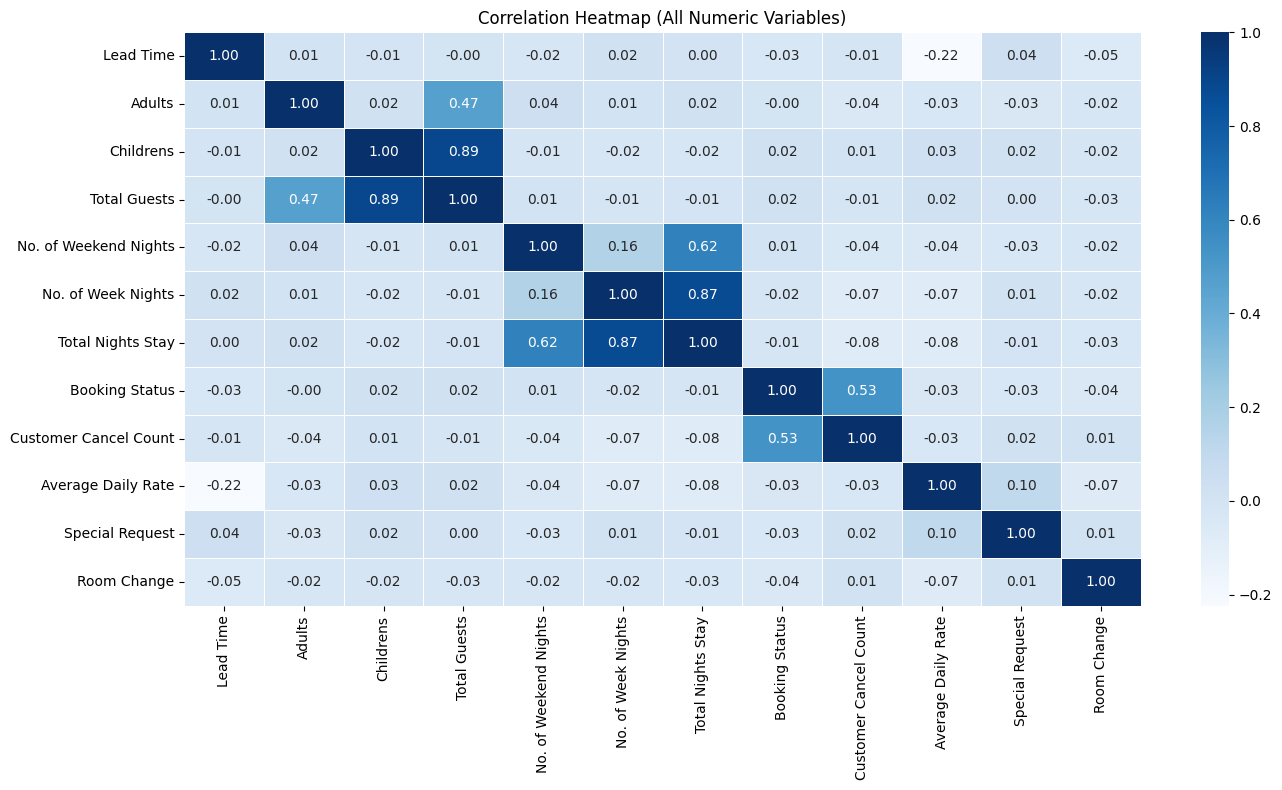

In [45]:
#Correlation between all variables
plt.figure(figsize=(16,10))
# Clean column names
df.columns = df.columns.str.strip()
# Create Room Change column
df['Room Change'] = (df['Reserved Room Type'] != df['Assigned Room Type']).astype(int)
# Select all numeric columns automatically
corr = df.corr(numeric_only=True)
# Plot heatmap
plt.figure(figsize=(14,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    linewidths=0.5,
    fmt='.2f'
)
plt.title("Correlation Heatmap (All Numeric Variables)")
plt.tight_layout()
plt.show()

# Correlation Analysis
### Key Insights
- Strong relationship between Total Guests and Childrens (0.89), indicating family-based bookings.
- Total Nights Stay is highly influenced by Week Nights (0.87) and moderately by weekend stays.
- Booking Status and Customer Cancel Count (0.53) show a moderate positive relationship, indicating that past cancellation    behavior is associated with future cancellations.

### Weak Relationships
- Average Daily Rate (ADR) has very low correlation with cancellations → pricing is not a major factor.
- Lead Time shows minimal impact on booking cancellation behavior.
- Room Change has very weak correlation → reassignment does not significantly affect customers.

### Conclusion
- Cancellations are mainly influenced by customer behavior rather than pricing or booking timing.
- No single factor strongly determines cancellations, indicating a multi-factor impact.



# Overall Conclusion

- The majority of bookings are successfully completed (68.4%), but cancellations (31.6%) are significant and require attention.  
- Customers mainly prefer **Resort Hotels** and **Standard rooms**, indicating demand for affordable and leisure-oriented stays.  
- Most bookings are for **short stays (2–4 nights)** and are made within a **short to medium lead time**, showing a preference for quick trip planning.  
- **Pricing (ADR)** and **Lead Time** have very weak influence on cancellations, indicating they are not primary decision factors.  
- **Booking channel** plays an important role, with online platforms showing higher booking volume as well as higher cancellations.  
- **Customer behavior**, especially past cancellation history, shows a moderate relationship with current cancellations.  
- Strong relationships exist between guest composition and stay duration (e.g., guests vs children, nights vs weekdays), but these do not directly drive cancellations.  
- Clear **seasonality trends** are observed, with peak bookings in mid-year months and higher cancellation risk in certain months like November.  
- Overall, hotel booking behavior is stable and predictable, but cancellations are influenced by multiple factors rather than a single variable.

# Business Insights

- Focus on reducing cancellations from online booking channels, as they show the highest cancellation rates.  
- Optimize pricing during peak months (February, October) to maximize revenue, as ADR varies with seasonality.  
- Target short-stay customers with tailored offers, as most bookings are for 2–4 nights.  
- Improve room allocation to reduce unnecessary upgrades, as there is a mismatch between reserved and assigned room types.